In [53]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error,mean_absolute_error

#load dataset
data = pd.read_excel(r"../df.xlsx")
df = data.iloc[27:,:] # from 1992-2025
df.head()

print(df.info())

print(df.shape)

df = df.sort_values('Date')

df.set_index('Date', inplace=True)
df.head(3)


<class 'pandas.DataFrame'>
RangeIndex: 67 entries, 27 to 93
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       67 non-null     datetime64[us]
 1   Year                       67 non-null     int64         
 2   Season                     67 non-null     str           
 3   Sown_Extent_Major          67 non-null     int64         
 4   Sown_Extent_Minor          67 non-null     int64         
 5   Sown_Extent_Rainfall       67 non-null     int64         
 6   Sown_Extent_Total          67 non-null     int64         
 7   Harvested_Extent_Major     67 non-null     int64         
 8   Harvested_Extent_Minor     67 non-null     int64         
 9   Harvested_Extent_Rainfall  67 non-null     int64         
 10  Harvested_Extent_Total     67 non-null     int64         
 11  Avg_Yield_Major            67 non-null     int64         
 12  Avg_Yield_Minor     

,Year,Season,Sown_Extent_Major,Sown_Extent_Minor,Sown_Extent_Rainfall,Sown_Extent_Total,Harvested_Extent_Major,Harvested_Extent_Minor,Harvested_Extent_Rainfall,Harvested_Extent_Total,...,Fung_Used,Fung_NotUsed,Short_Grain_Red,Long_Grain_Red,Short_Grain_White,Long_Grain_White,Other(seed_variety),New_Improved,Old_Improved,Traditional
Date,,,,,,,,,,,,,,,,,,,,,
1992-04-01,1992,Yala,130502,49825,74657,254983,122937,47463,72833,243236,...,24.10,75.90,0.0,0.0,0.0,0.0,0.0,90.55,0.81,8.64
1992-09-01,1993,Maha,247069,130475,168145,545689,245058,127580,165398,538060,...,24.32,75.68,0.0,0.0,0.0,0.0,0.0,89.89,1.43,8.68
1993-04-01,1993,Yala,162398,45118,81088,288605,160944,43231,77531,281706,...,18.27,81.73,0.0,0.0,0.0,0.0,0.0,90.25,1.12,8.63


In [54]:
ts = df["Production"]
ts.tail()

Date
2023-04-01    1817.39
2023-09-01    2721.96
2024-04-01    1976.50
2024-09-01    2745.30
2025-04-01    2308.40
Name: Production, dtype: float64

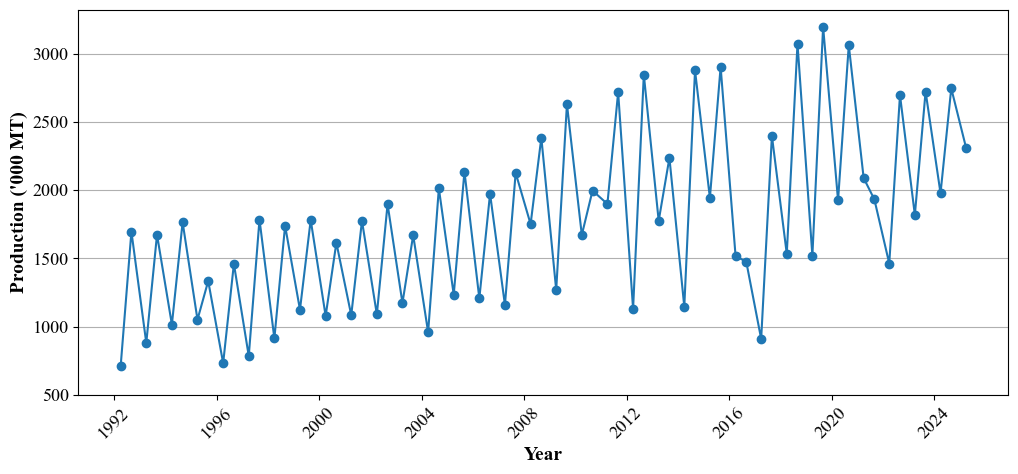

In [55]:
plt.figure(figsize=(12,5))
plt.plot(ts,marker="o",linewidth=1.5)

# plt.title("Paddy Production Time Series")
plt.xlabel("Year",fontsize=14,fontweight='bold',fontname='Times New Roman')
plt.ylabel("Production ('000 MT)",fontsize=14,fontweight='bold',fontname='Times New Roman')
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.ylim(500,)
plt.xticks(fontsize=13, fontname='Times New Roman')
plt.yticks(fontsize=13, fontname='Times New Roman')

plt.show()

In [56]:
# train / test split
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 53
Test size: 14


In [57]:
from statsmodels.tsa.stattools import adfuller, kpss
def adf_test(series, label="Series"):
    result = adfuller(series, autolag="AIC")
    p = result[1]
    print(f"\n  ADF Test [{label}]")
    print(f"    Statistic : {result[0]:.4f}")
    print(f"    p-value   : {p:.4f}")
    # print(f"    Critical 5%: {result[4]['5%']:.4f}")
    print(f"    → {'✅ STATIONARY' if p < 0.05 else '❌ NON-STATIONARY — differencing needed'}")
    return p

adf_test(ts, "Original")


  ADF Test [Original]
    Statistic : -0.4794
    p-value   : 0.8960
    → ❌ NON-STATIONARY — differencing needed


np.float64(0.8959678536519408)

In [58]:
# Automatically Find Best SARIMA Model
auto_model = auto_arima(train, 
                   seasonal=True,
                   test='adf', 
                   m=2, 
                   stepwise=True, 
                   suppress_warnings=True,
                   trace=True)

print(auto_model)

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,1,1)[2] intercept   : AIC=736.255, Time=0.44 sec
 ARIMA(0,0,0)(0,1,0)[2] intercept   : AIC=767.312, Time=0.01 sec
 ARIMA(1,0,0)(1,1,0)[2] intercept   : AIC=750.926, Time=0.06 sec
 ARIMA(0,0,1)(0,1,1)[2] intercept   : AIC=733.322, Time=0.10 sec
 ARIMA(0,0,0)(0,1,0)[2]             : AIC=765.557, Time=0.01 sec
 ARIMA(0,0,1)(0,1,0)[2] intercept   : AIC=751.915, Time=0.04 sec
 ARIMA(0,0,1)(1,1,1)[2] intercept   : AIC=734.581, Time=0.18 sec
 ARIMA(0,0,1)(0,1,2)[2] intercept   : AIC=734.320, Time=0.16 sec
 ARIMA(0,0,1)(1,1,0)[2] intercept   : AIC=744.920, Time=0.07 sec
 ARIMA(0,0,1)(1,1,2)[2] intercept   : AIC=inf, Time=0.16 sec
 ARIMA(0,0,0)(0,1,1)[2] intercept   : AIC=inf, Time=0.04 sec
 ARIMA(1,0,1)(0,1,1)[2] intercept   : AIC=734.581, Time=0.19 sec
 ARIMA(1,0,0)(0,1,1)[2] intercept   : AIC=735.088, Time=0.08 sec
 ARIMA(0,0,1)(0,1,1)[2]             : AIC=735.175, Time=0.06 sec

Best model:  ARIMA(0,0,1)(0,1,1)[2] intercept
Total fi

In [59]:

# Generate a summary of the best model found
print(auto_model.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                   53
Model:             SARIMAX(0, 0, 1)x(0, 1, 1, 2)   Log Likelihood                -362.661
Date:                           Sun, 31 May 2026   AIC                            733.322
Time:                                   10:59:51   BIC                            741.049
Sample:                                        0   HQIC                           736.275
                                            - 53                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     35.2591     15.025      2.347      0.019       5.811      64.708
ma.L1          0.4345      0.184      2.367

In [60]:
print(auto_model.fit(train))

 ARIMA(0,0,1)(0,1,1)[2] intercept


In [61]:
forecast = auto_model.predict(n_periods=len(test))
forecast

C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\User\AppData\Roaming\Python\Python314\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


53    2495.565291
54    1631.225599
55    2561.673592
56    1666.484654
57    2596.932647
58    1701.743709
59    2632.191702
60    1737.002765
61    2667.450757
62    1772.261820
63    2702.709813
64    1807.520875
65    2737.968868
66    1842.779930
dtype: float64

In [62]:
dates = test.index
forecast_df = pd.DataFrame(index=dates)

forecast_df['Prediction'] = forecast.values.round(2)

# Season
forecast_df['Season'] = np.where(
    dates.month == 4,
    'Yala',
    'Maha'
)

# Agricultural year
forecast_df['Year'] = np.where(
    dates.month == 4,          # Yala starts in April
    dates.year,
    dates.year + 1            # Maha starts in September, assigned to next year
)

forecast_df = forecast_df[['Prediction', 'Year', 'Season']]

forecast_df

,Prediction,Year,Season
Date,,,
2018-09-01,2495.57,2019,Maha
2019-04-01,1631.23,2019,Yala
2019-09-01,2561.67,2020,Maha
2020-04-01,1666.48,2020,Yala
2020-09-01,2596.93,2021,Maha
2021-04-01,1701.74,2021,Yala
2021-09-01,2632.19,2022,Maha
2022-04-01,1737.00,2022,Yala
2022-09-01,2667.45,2023,Maha


In [63]:
# forecast_df = pd.DataFrame(forecast.values.round(2), index= test.index, columns=['Prediction'])


# forecast_df

In [64]:

# pd.concat([ts, forecast_df], axis=1).plot(figsize=(12,6))

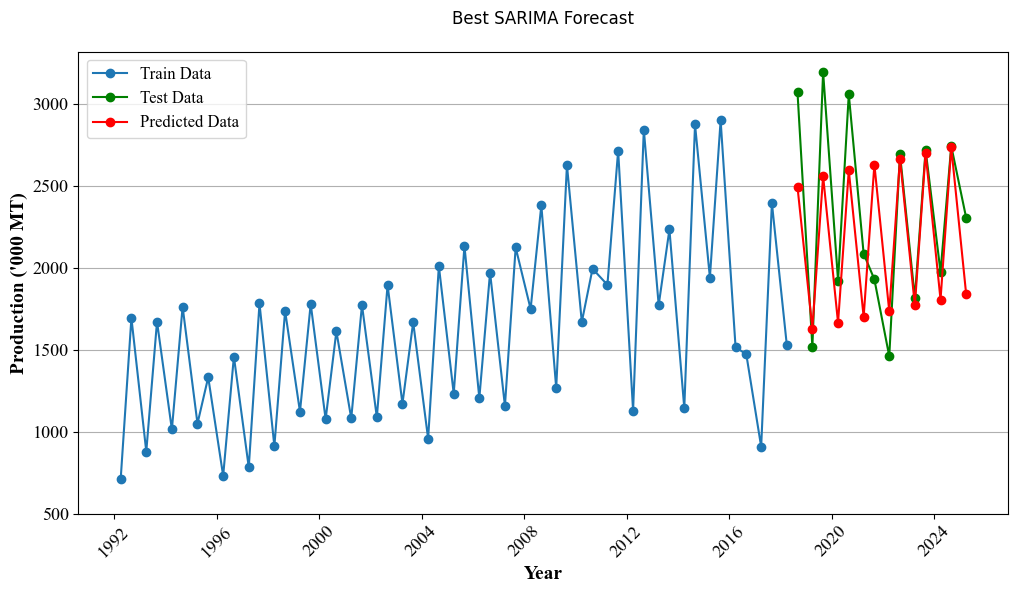

In [65]:
#Plot Forecast
plt.figure(figsize=(12,6))


plt.plot(train.index, train, label="Train Data",marker="o",linewidth=1.5)
plt.plot(test.index, test, label="Test Data", color="green",marker="o",linewidth=1.5)
plt.plot(test.index, forecast, label="Predicted Data", color="red",marker="o",linewidth=1.5)

plt.legend(prop={'size': 12, 'family':'Times New Roman'}  )

plt.title("Best SARIMA Forecast",pad=20)

plt.ylim(500,)


plt.xlabel("Year",fontsize=14,fontweight='bold',fontname='Times New Roman')
plt.ylabel("Production ('000 MT)",fontsize=14,fontweight='bold',fontname='Times New Roman')

plt.grid(axis='y')
plt.xticks(rotation=45)

plt.xticks(fontsize=13, fontname='Times New Roman')
plt.yticks(fontsize=13, fontname='Times New Roman')

plt.show()

### Interpretation of plots in plot diagnostics

Standardized residual: The residual errors seem to fluctuate around a mean of zero and have a uniform variance.

Histogram: The density plot suggest normal distribution with mean slighlty shifted towards right.

Theoretical Quantiles: Mostly the dots fall perfectly in line with the red line. Any significant deviations would imply the distribution is skewed.

Correlogram: The Correlogram, (or ACF plot) shows the residual errors are not autocorrelated. The ACF plot would imply that there is some pattern in the residual errors which are not explained in the model. So we will need to look for more X’s (predictors) to the model.

Overall, the model seems to be a good fit. So, let's use it to forecast.

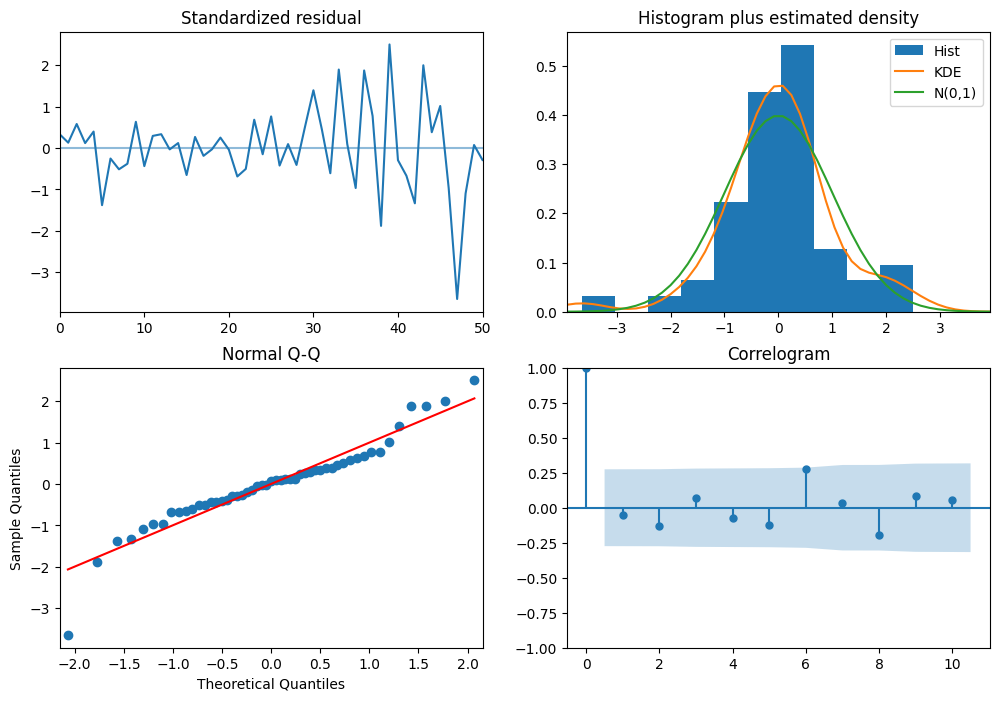

In [66]:
# Diagnostic plots
auto_model.plot_diagnostics(figsize=(12,8))
plt.show()

In [67]:
#Evaluate Model
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast) * 100
mae = mean_absolute_error(test, forecast)

print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}")
print(f"MAE : {mae:.2f}")

RMSE : 377.59
MAPE : 12.96
MAE : 295.97
